In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
import os

In [18]:
import os
from dotenv import load_dotenv
from langchain_mistralai import ChatMistralAI
from mistralai.client import Mistral

load_dotenv()

# Approach A: Passing the environment variable explicitly
model = ChatMistralAI(
    model="mistral-large-latest",
    temperature=0.7,
    mistral_api_key=os.getenv("mistral_APIKEY")
)

# Approach B: Passing your already-verified working client object directly
# client = Mistral(api_key=os.getenv("mistral_APIKEY"))
# model = ChatMistralAI(model="mistral-large-latest", mistral_client=client)

response = model.invoke("What is a state graph?")
print(response.content)

A **state graph** (also known as a **state transition graph** or **finite state machine graph**) is a graphical representation of a **finite state machine (FSM)** or a **state transition system**. It visually depicts the states, transitions, and actions of a system as it moves from one state to another in response to inputs or events.

### **Key Components of a State Graph:**
1. **States (Nodes)**
   - Represent distinct conditions or modes of the system.
   - Drawn as circles or rectangles.
   - Example: `Idle`, `Running`, `Paused`, `Error`.

2. **Transitions (Edges)**
   - Represent the movement from one state to another.
   - Drawn as directed arrows (→) between states.
   - Labeled with the **triggering event** or **input condition** that causes the transition.
   - Example: `Start → Running`, `Pause → Paused`.

3. **Initial State**
   - The starting state of the system (often marked with an incoming arrow or a special symbol like a filled circle).
   - Example: `Idle` (initial sta

In [10]:
class LLMState(TypedDict):
    question:str
    answer:str

In [19]:
def llm_qa(state:LLMState)->LLMState:
    question = state['question']
    prompt = f"Answer the Following QUESTION: {question}"
    answer = model.invoke(prompt).content
    state['answer'] = answer
    return state

In [24]:
initial_state = LLMState(question="new features of Ai")
final_state = workflow.invoke(initial_state)
print(final_state)

{'question': 'new features of Ai', 'answer': 'Artificial Intelligence (AI) is evolving rapidly, with new features and advancements emerging across various domains. Here are some of the **latest and most impactful AI features** as of 2024:\n\n---\n\n### **1. Multimodal AI (Text + Image + Audio + Video)**\n   - **What it is**: AI models that process and generate **multiple data types** (text, images, audio, video) simultaneously.\n   - **Examples**:\n     - **Google Gemini** (handles text, code, images, audio, and video in one model).\n     - **OpenAI’s GPT-4o** (real-time voice, vision, and text interaction).\n     - **Meta’s Llama 3** (multimodal capabilities in development).\n   - **Use Cases**:\n     - Real-time video analysis (e.g., medical imaging + diagnostic reports).\n     - AI assistants that describe images, generate code from sketches, or create videos from text.\n\n---\n\n### **2. Agentic AI (Autonomous AI Agents)**\n   - **What it is**: AI systems that **act independently**

In [22]:
#create graph
graph = StateGraph(LLMState)
#define nodes
graph.add_node("llm_qa" , llm_qa)
#edges
graph.add_edge(START, "llm_qa")
graph.add_edge("llm_qa", END)
#compile workflow
workflow = graph.compile()

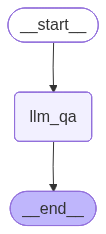

In [23]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())